# Frequency Check

In [6]:
import pandas as pd
import numpy as np

FILE_PATH = "../Datasets/Processed_Data/Unlabeled_Data_With_GPS/Europe/Austria/Phone 7/Mirabellplatz_AccelerometerData.csv"

df = pd.read_csv(FILE_PATH)

# Inter-sample intervals in seconds (attr_time is ms)
dt = df["timestamp"].diff().dropna() / 1000.0
dt = dt[dt > 0]  # drop zero/negative gaps (duplicates or resets)

freq_hz = 1.0 / dt

# Round to nearest integer Hz to find the dominant frequency
dominant_hz = int(freq_hz.round().mode()[0])

print(f"{'Samples':<20}: {len(df)}")
print(f"{'Duration':<20}: {(df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]) / 1000:.2f} s")
print()
print(f"{'Dominant freq':<20}: {dominant_hz} Hz")
print(f"{'Mean freq':<20}: {freq_hz.mean():.2f} Hz")
print(f"{'Median freq':<20}: {freq_hz.median():.2f} Hz")
print(f"{'Std freq':<20}: {freq_hz.std():.2f} Hz")
print(f"{'Min / Max freq':<20}: {freq_hz.min():.2f} / {freq_hz.max():.2f} Hz")


FileNotFoundError: [Errno 2] No such file or directory: '../Datasets/Processed_Data/Unlabeled_Data_With_GPS/Europe/Austria/Phone 7/Mirabellplatz_AccelerometerData.csv'

# Data Check

In [7]:
def remove_stalled_regions(
    df: pd.DataFrame,
    sampling_rate: int = 50,
    window_seconds: float = 120.0,
) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)

    magnitude = np.sqrt(df['attr_x']**2 + df['attr_y']**2 + df['attr_z']**2)
    diff = magnitude.diff().abs().fillna(0)

    global_mean_diff = diff.mean()

    window_samples = int(window_seconds * sampling_rate)
    window_mean_diff = diff.rolling(window=window_samples, center=True, min_periods=1).mean()

    remove_mask = (window_mean_diff < global_mean_diff).values  # numpy array, index-safe

    clean_df = df[~remove_mask].reset_index(drop=True)
    print(f"Global mean diff: {global_mean_diff:.4f} | Removed: {remove_mask.sum()} / {len(df)} → {len(clean_df)} remaining")
    return clean_df


In [2]:
# data processing pipeline

import numpy as np
from scipy.signal import butter, sosfiltfilt
from scipy import stats
from scipy.ndimage import label

# Trimping function to remove start/end artifacts
def trim_signal(data, trim_percent=0.1):
    """Trim a percentage of samples from the start and end of the signal."""
    trim_count = int(len(data) * trim_percent)

    return data[trim_count:-trim_count].reset_index(drop=True)

# Butterworth filter design using SOS for stability
def _design_butterworth_filter(cutoff, fs, btype, order=4):
    """Design a Butterworth filter and return SOS coefficients."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    if normal_cutoff >= 1.0:
        raise ValueError(
            f"lowpass_cutoff ({cutoff} Hz) must be < Nyquist ({nyquist} Hz) for fs={fs} Hz."
        )

    return butter(order, normal_cutoff, btype=btype, output='sos')


def run_butterworth(data, fs = 50, highpass_cutoff=0.3, lowpass_cutoff=15, order=4):
    """
    Apply bandpass filtering (highpass + lowpass) to X, Y, Z accelerometer columns.
    Uses SOS format for numerical stability.
    """
    # Design filters once, reuse across axes
    sos_high = _design_butterworth_filter(highpass_cutoff, fs, btype='high', order=order)
    sos_low  = _design_butterworth_filter(lowpass_cutoff,  fs, btype='low',  order=order)

    cols = ['attr_x', 'attr_y', 'attr_z']
    raw = data[cols].values  # (N, 3) — process all axes at once

    filtered = sosfiltfilt(sos_high, raw, axis=0)
    filtered = sosfiltfilt(sos_low,  filtered, axis=0)

    data_filtered = data.copy()
    data_filtered[cols] = filtered

    return data_filtered


# Hampel filter implementation
def _hampel_filter_vectorized(signal: np.ndarray, window_size: int = 10, n_sigmas: float = 3) -> np.ndarray:
    """
    Fully vectorized Hampel filter — significantly faster for large arrays.
    Uses stride tricks to build a sliding window matrix in one operation.
    """
    if not isinstance(signal, np.ndarray):
        signal = np.asarray(signal, dtype=float)

    L = len(signal)
    new_signal = signal.copy()

    # Build sliding window view using stride tricks (zero-copy)
    win_full = 2 * window_size + 1
    shape = (L - 2 * window_size, win_full)
    strides = (signal.strides[0], signal.strides[0])
    windows = np.lib.stride_tricks.as_strided(signal, shape=shape, strides=strides)

    medians = np.median(windows, axis=1)
    mads = stats.median_abs_deviation(windows, axis=1)

    threshold = n_sigmas * np.maximum(mads, 1e-10)
    center_vals = signal[window_size : L - window_size]
    outlier_mask = np.abs(center_vals - medians) > threshold 


    new_signal[window_size : L - window_size][outlier_mask] = medians[outlier_mask]

    return new_signal


def run_hampel(data, vectorized: bool = True):
    """
    Apply Hampel filter to attr_x, attr_y, attr_z columns.

    Args:
        data: DataFrame with columns attr_x, attr_y, attr_z
        vectorized: Use fast vectorized implementation (default: True)
    """

    required_cols = ['attr_x', 'attr_y', 'attr_z']
    missing = [c for c in required_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    data_filtered = data.copy()

    # Process all columns in a single loop instead of repeating code
    for col in required_cols:
        data_filtered[col] = _hampel_filter_vectorized(data[col].values, window_size=10, n_sigmas=3)

    return data_filtered

# Remove stalled (flat/motionless) regions from accelerometer data
def remove_stalled_regions(
    df: pd.DataFrame,
    sampling_rate: int = 50,
    change_threshold: float = 1e-5,
    min_stall_seconds: float = 2.0
) -> pd.DataFrame:
    """
    Remove stalled (flat/motionless) regions from accelerometer data.

    Args:
        df: DataFrame with columns attr_x, attr_y, attr_z
        sampling_rate: Samples per second
        change_threshold: Max diff magnitude to consider a point "flat"
        min_stall_seconds: Minimum duration (seconds) to classify as a stall

    Returns:
        DataFrame with stalled regions removed and index reset
    """
    required_cols = ['attr_x', 'attr_y', 'attr_z']
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    if sampling_rate <= 0:
        raise ValueError("sampling_rate must be positive")
    if min_stall_seconds <= 0:
        raise ValueError("min_stall_seconds must be positive")

    df = df.copy()

    # Compute magnitude
    magnitude = np.sqrt(df['attr_x']**2 + df['attr_y']**2 + df['attr_z']**2)

    # Use np.diff directly (faster than pandas .diff())
    diff = np.empty(len(magnitude))
    diff[0] = 0.0
    diff[1:] = np.abs(np.diff(magnitude))

    # Identify flat points
    flat_mask = diff < change_threshold

    # Convert duration to samples
    min_samples = int(min_stall_seconds * sampling_rate)

    # instead of Python for-loop over every sample
    labeled_array, num_features = label(flat_mask)

    remove_mask = np.zeros(len(df), dtype=bool)

    for region_id in range(1, num_features + 1):
        region_indices = np.where(labeled_array == region_id)[0]
        if len(region_indices) >= min_samples:
            remove_mask[region_indices] = True

    return df.loc[~remove_mask].reset_index(drop=True)


def resample_data(
    df: pd.DataFrame,
    time_col: str = 'attr_time',
    signal_cols: list = None,
    target_hz: int = 100,
) -> pd.DataFrame:
    """
    Upsample sensor data to target_hz using linear interpolation.

    Assumes attr_time is in milliseconds. Existing timestamps are used as
    anchor points; new evenly-spaced timestamps at target_hz are interpolated
    between them.

    Args:
        df:          DataFrame containing the time column and signal columns.
        time_col:    Name of the timestamp column (ms).
        signal_cols: Columns to resample. Defaults to ['attr_x', 'attr_y', 'attr_z'].
        target_hz:   Desired output sample rate in Hz (default: 100).

    Returns:
        Resampled DataFrame with reset index.
    """
    if signal_cols is None:
        signal_cols = ['attr_x', 'attr_y', 'attr_z']

    df = df.copy().sort_values(time_col).reset_index(drop=True)

    t_orig = df[time_col].values.astype(np.float64)  # ms

    # Build evenly-spaced target timestamps at target_hz
    step_ms = 1000.0 / target_hz
    t_new = np.arange(t_orig[0], t_orig[-1] + step_ms, step_ms)

    # Clamp to original range to avoid extrapolation
    t_new = t_new[(t_new >= t_orig[0]) & (t_new <= t_orig[-1])]

    resampled = {time_col: t_new}
    for col in signal_cols:
        resampled[col] = np.interp(t_new, t_orig, df[col].values)

    # Carry over any extra non-signal columns (e.g. labels) via nearest lookup
    extra_cols = [c for c in df.columns if c not in signal_cols and c != time_col]
    if extra_cols:
        idx = np.searchsorted(t_orig, t_new, side='left').clip(0, len(df) - 1)
        for col in extra_cols:
            resampled[col] = df[col].values[idx]

    result = pd.DataFrame(resampled)
    print(
        f"Resampled: {len(df)} samples @ ~{1000/(np.diff(t_orig).mean()):.0f} Hz  →  "
        f"{len(result)} samples @ {target_hz} Hz"
    )
    return result


Found 25 accelerometer files
Resampled: 632718 samples @ ~49 Hz  →  1282857 samples @ 100 Hz


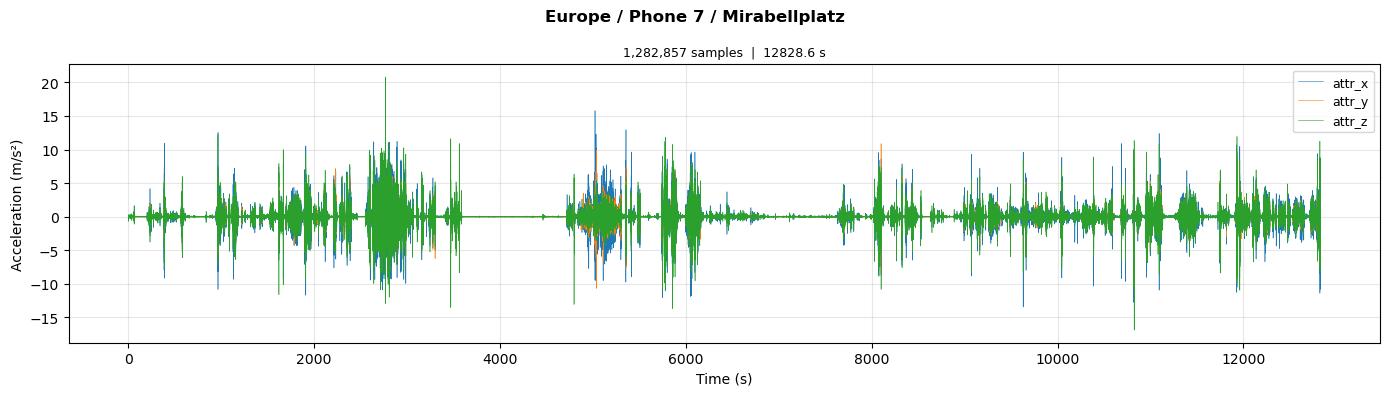

Resampled: 1092085 samples @ ~49 Hz  →  2214274 samples @ 100 Hz


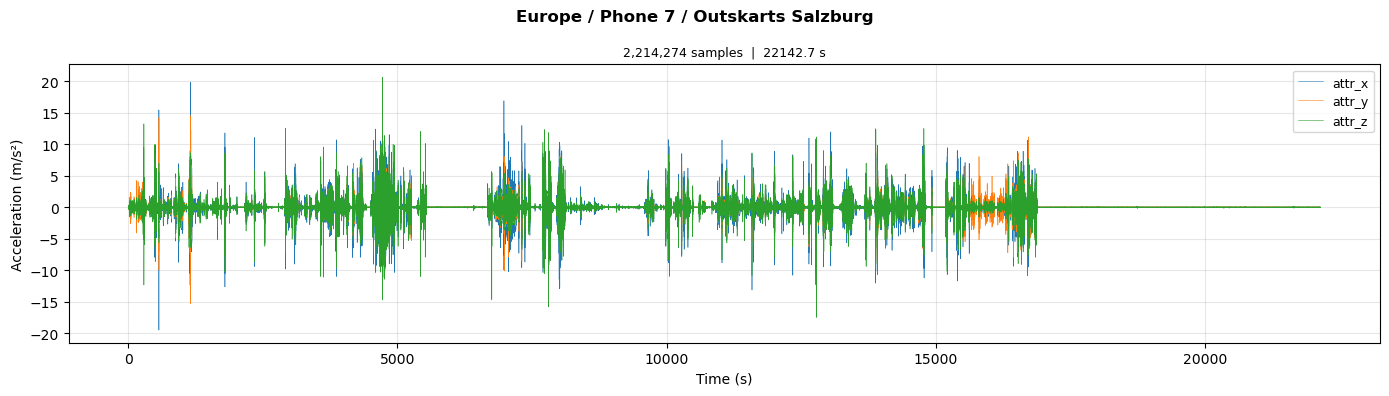

Resampled: 639725 samples @ ~50 Hz  →  1282855 samples @ 100 Hz


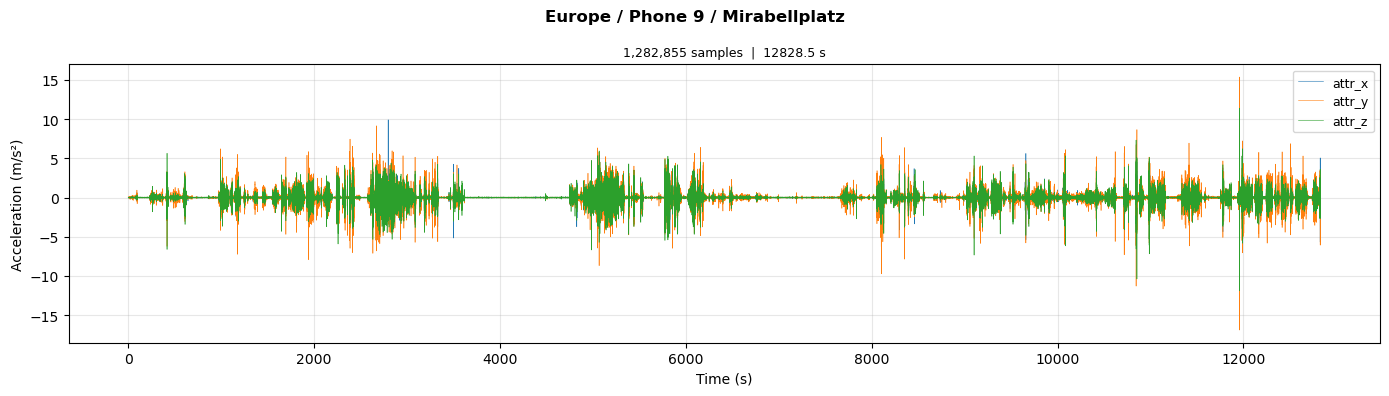

Resampled: 1104155 samples @ ~50 Hz  →  2214268 samples @ 100 Hz


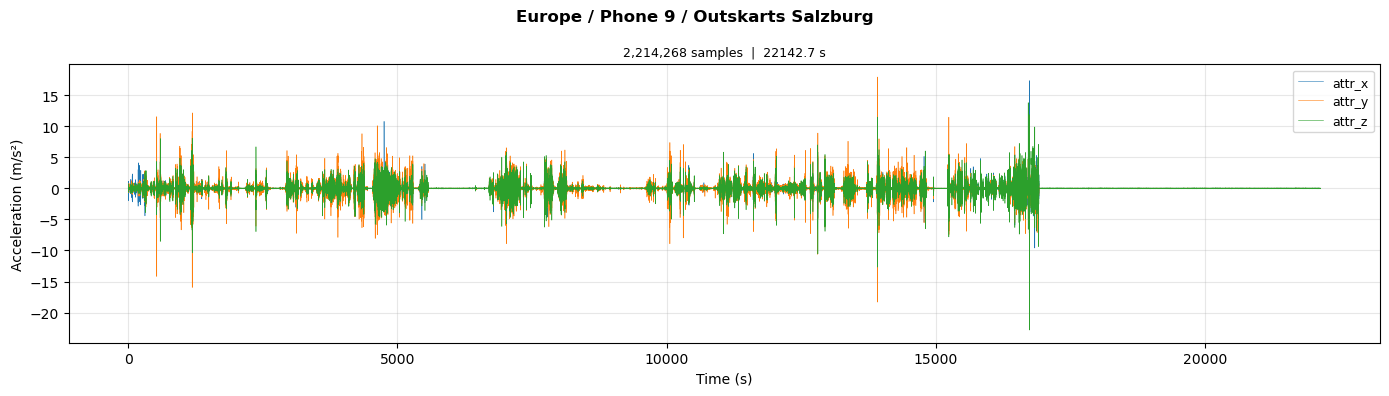

Resampled: 276846 samples @ ~49 Hz  →  561325 samples @ 100 Hz


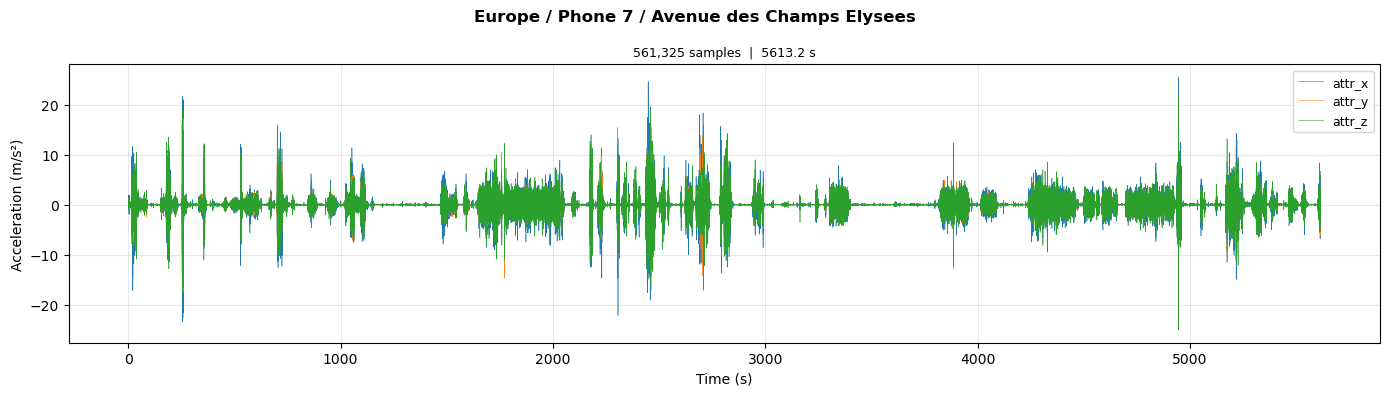

Resampled: 148391 samples @ ~49 Hz  →  300871 samples @ 100 Hz


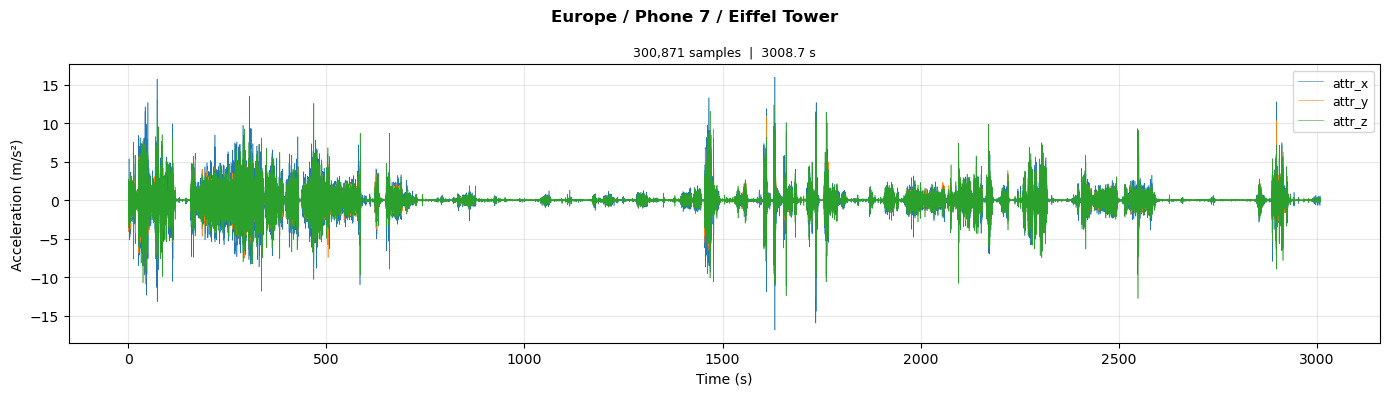

Resampled: 274311 samples @ ~49 Hz  →  556199 samples @ 100 Hz


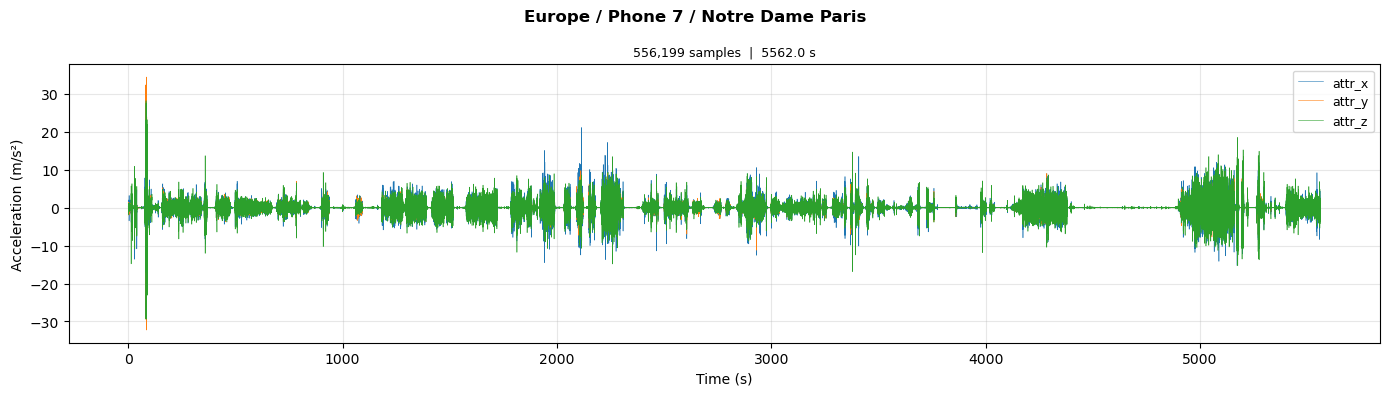

Resampled: 280172 samples @ ~50 Hz  →  561869 samples @ 100 Hz


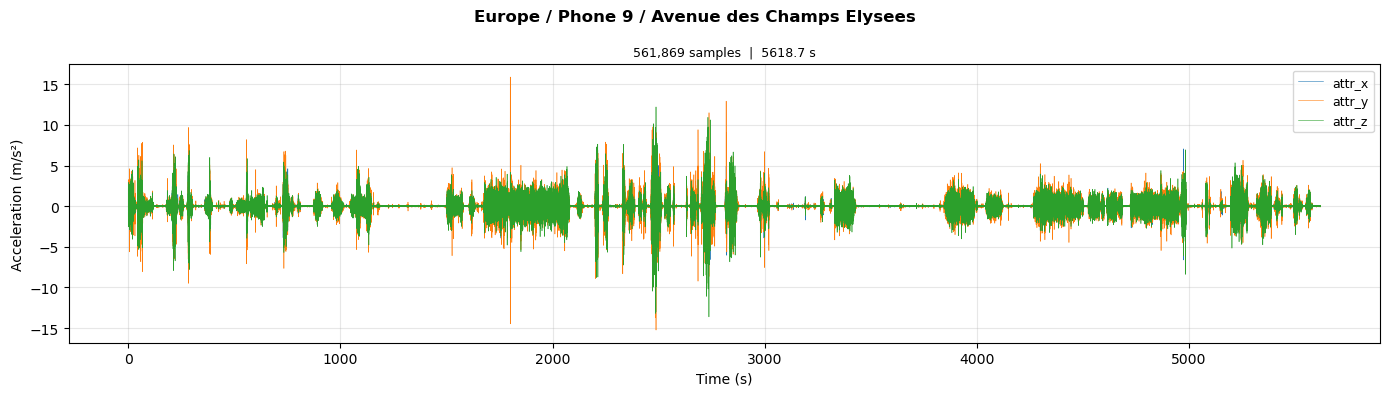

Resampled: 150030 samples @ ~50 Hz  →  300871 samples @ 100 Hz


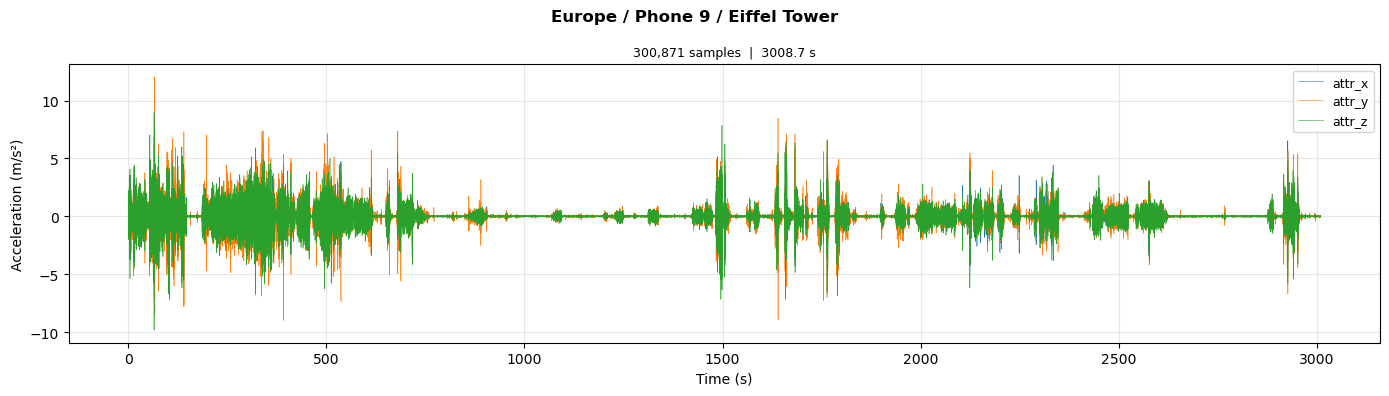

Resampled: 277343 samples @ ~50 Hz  →  556198 samples @ 100 Hz


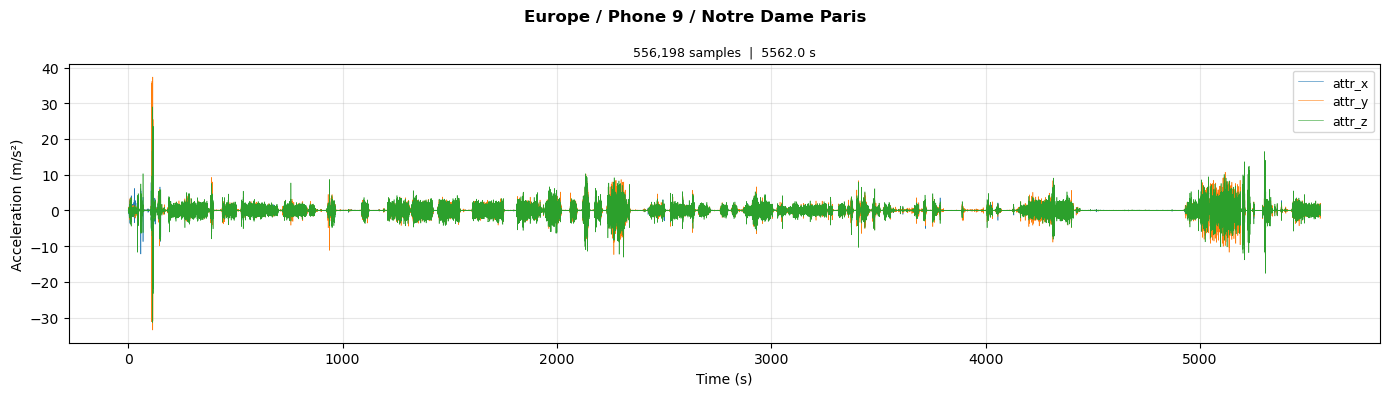

Resampled: 424106 samples @ ~42 Hz  →  1018447 samples @ 100 Hz


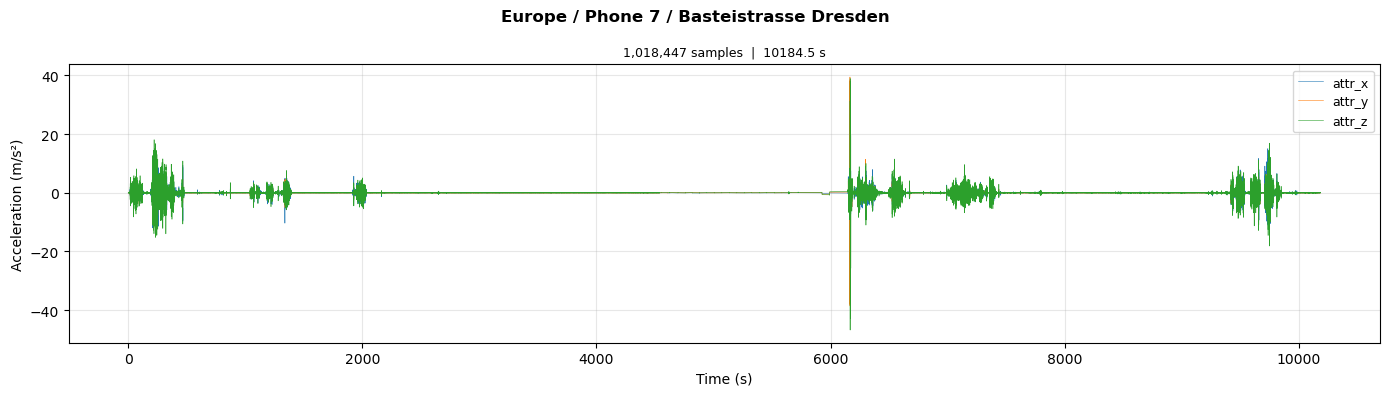

Resampled: 35197 samples @ ~49 Hz  →  71370 samples @ 100 Hz


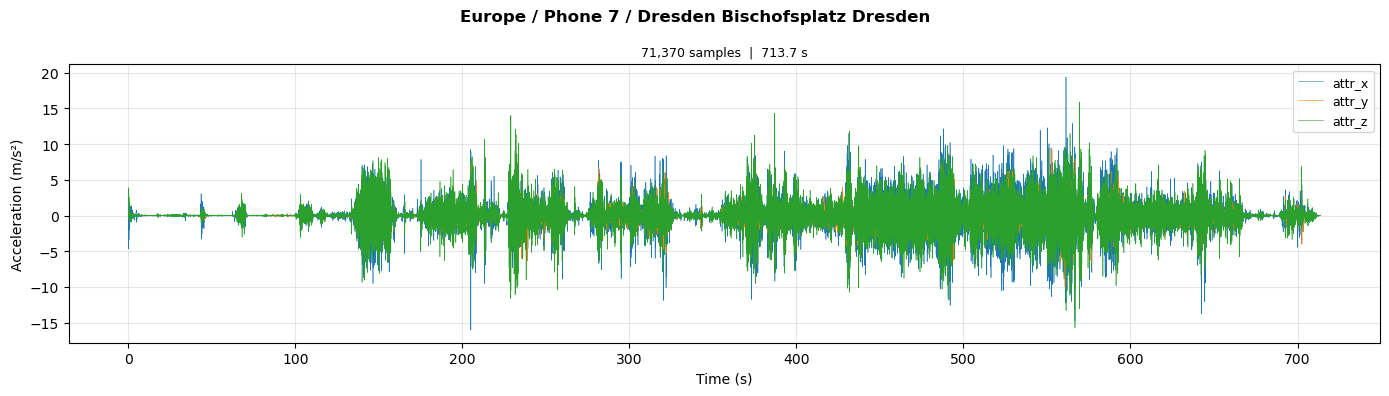

Resampled: 220003 samples @ ~49 Hz  →  446129 samples @ 100 Hz


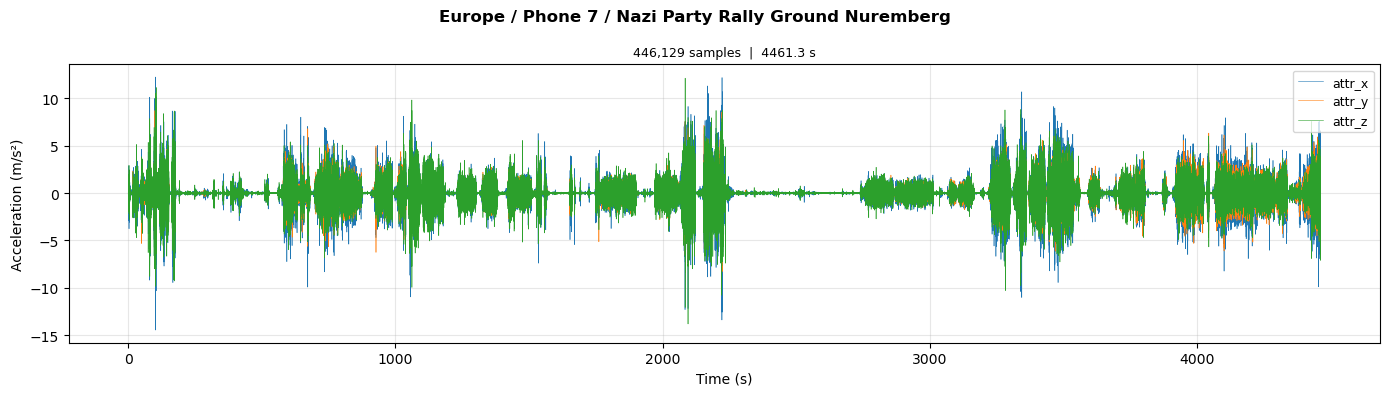

Resampled: 417063 samples @ ~13 Hz  →  3244936 samples @ 100 Hz


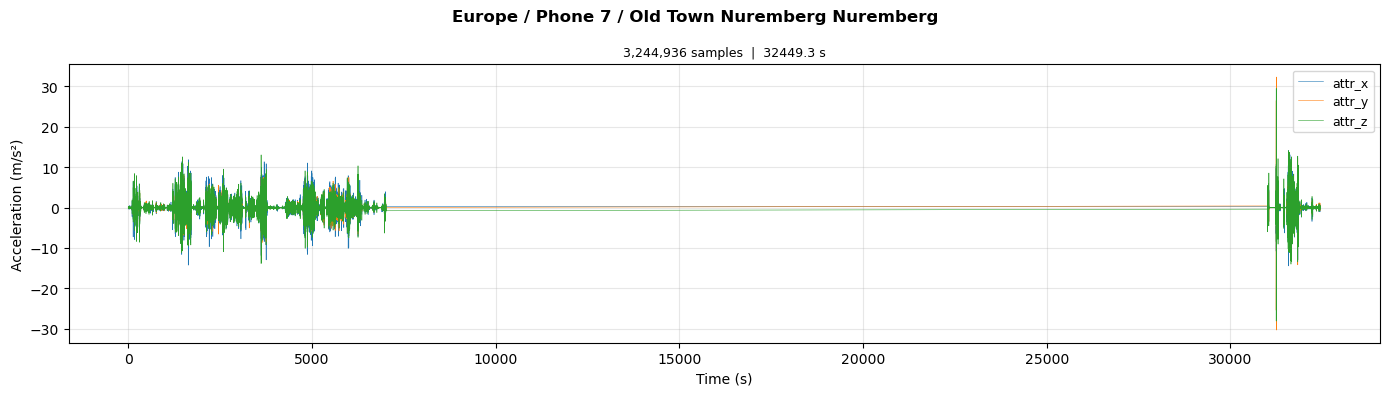

Resampled: 322075 samples @ ~49 Hz  →  653055 samples @ 100 Hz


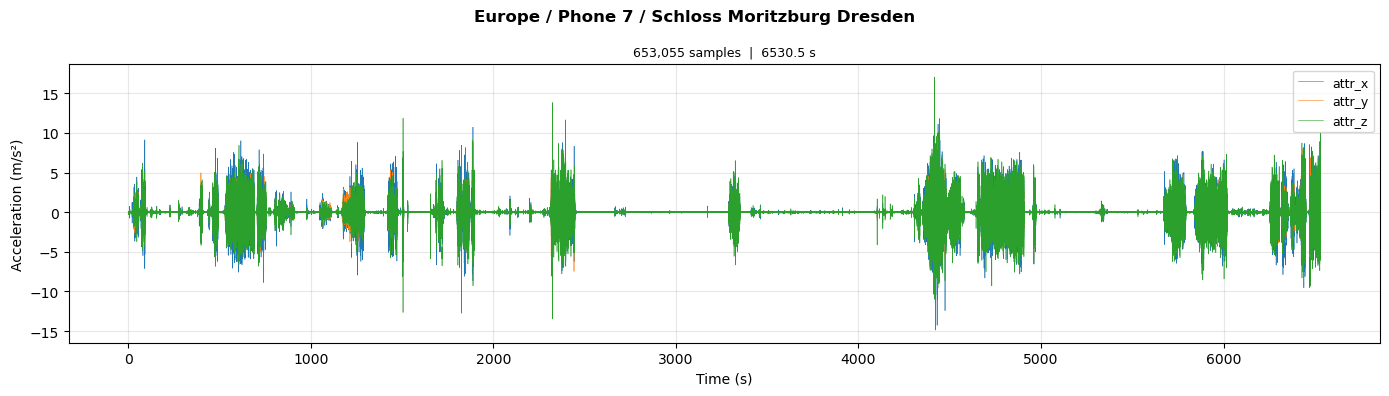

Resampled: 421345 samples @ ~42 Hz  →  1012715 samples @ 100 Hz


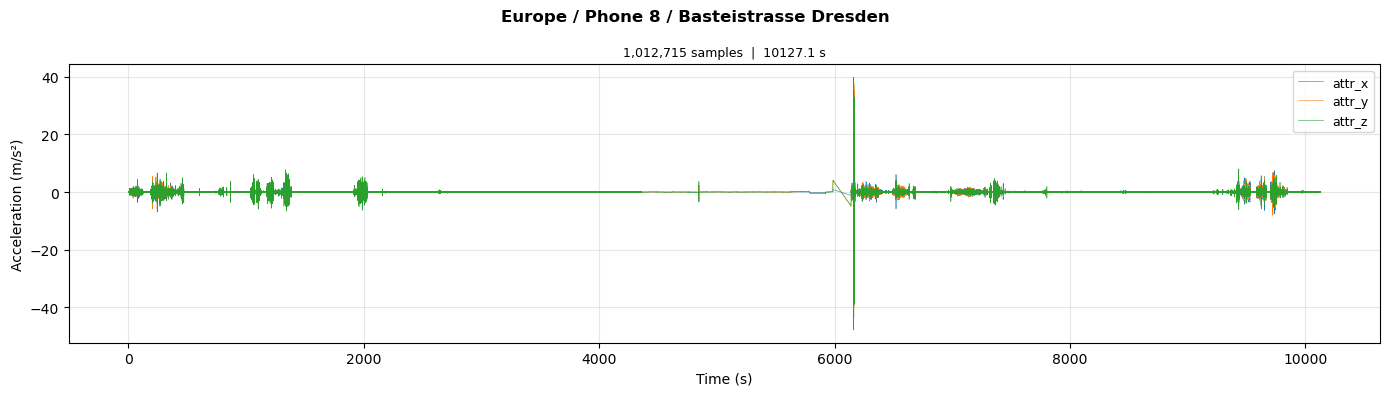

Resampled: 35922 samples @ ~50 Hz  →  71371 samples @ 100 Hz


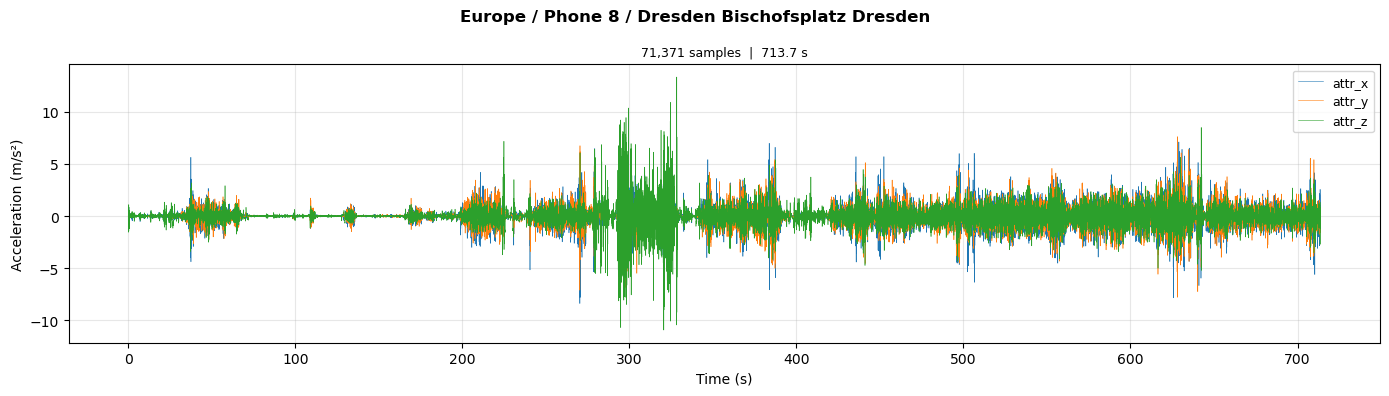

Resampled: 224529 samples @ ~50 Hz  →  446133 samples @ 100 Hz


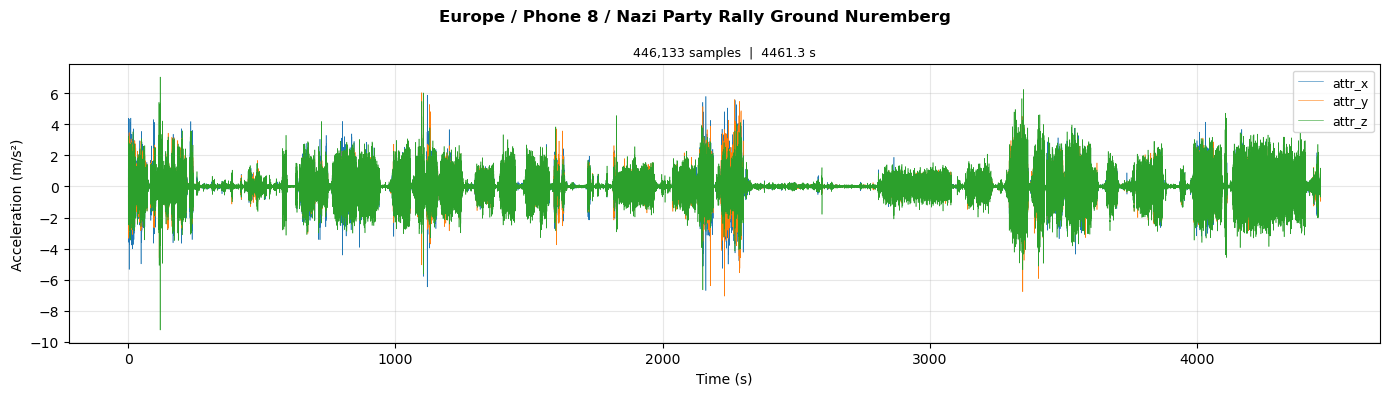

Resampled: 423828 samples @ ~13 Hz  →  3245343 samples @ 100 Hz


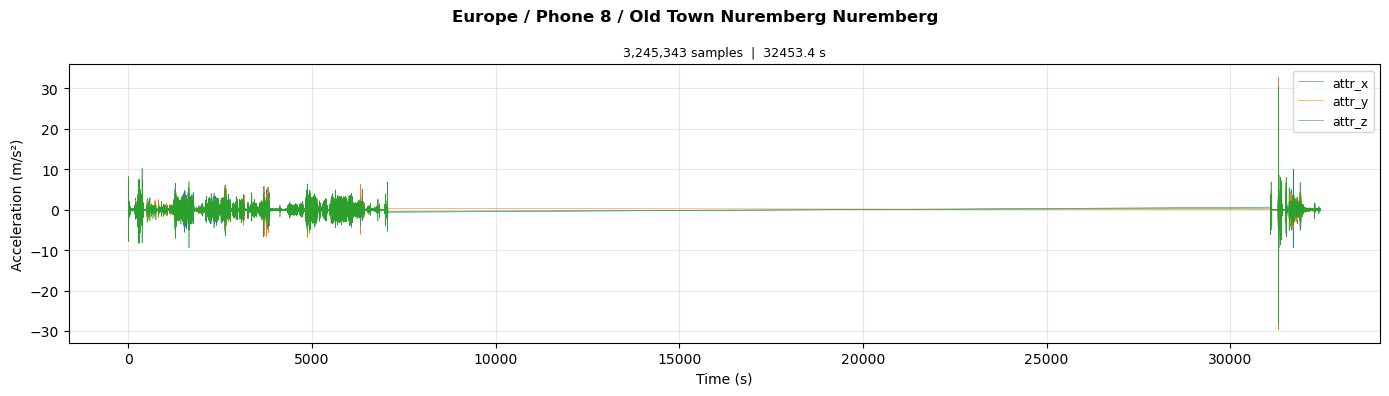

Resampled: 330732 samples @ ~50 Hz  →  657087 samples @ 100 Hz


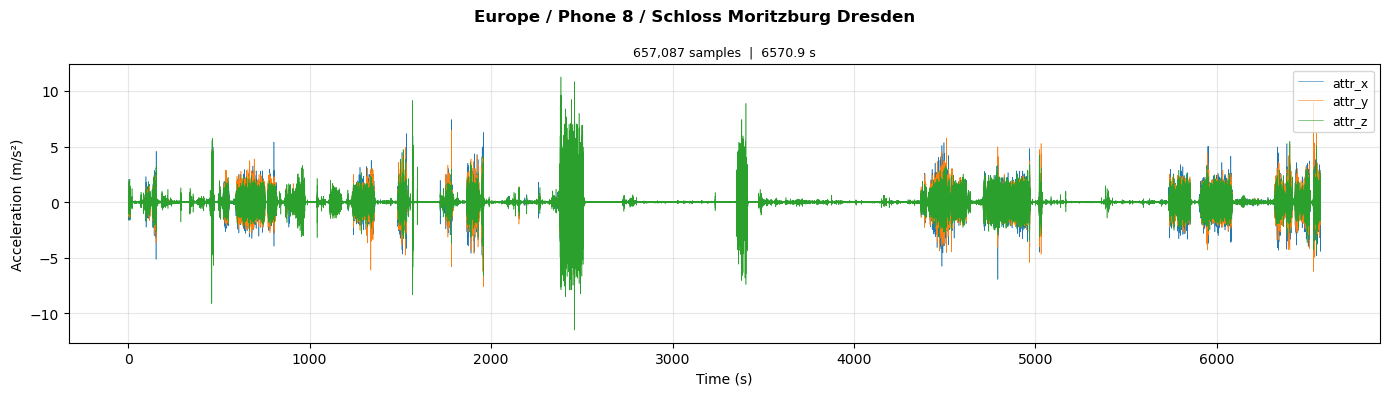

Resampled: 437944 samples @ ~44 Hz  →  1005131 samples @ 100 Hz


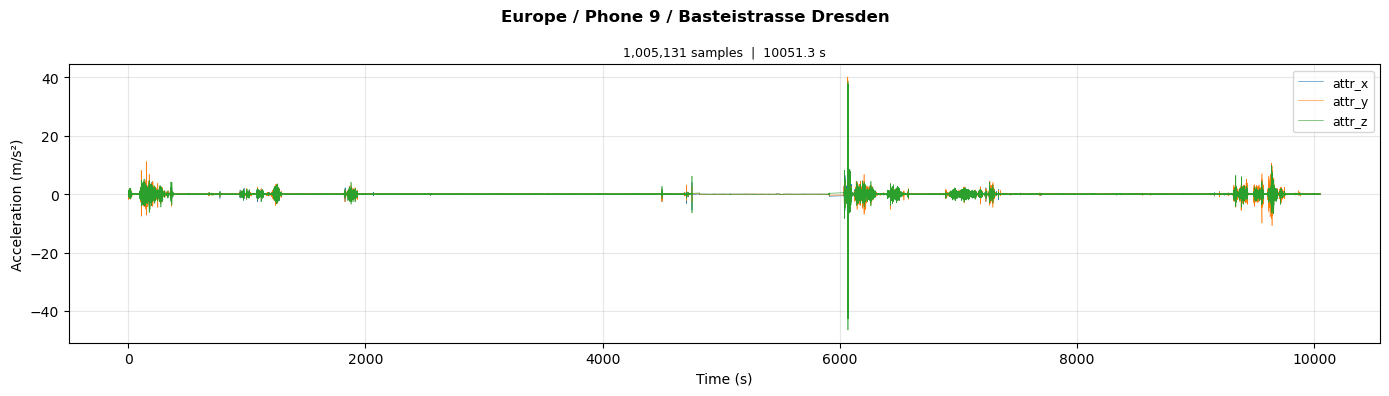

Resampled: 35587 samples @ ~50 Hz  →  71372 samples @ 100 Hz


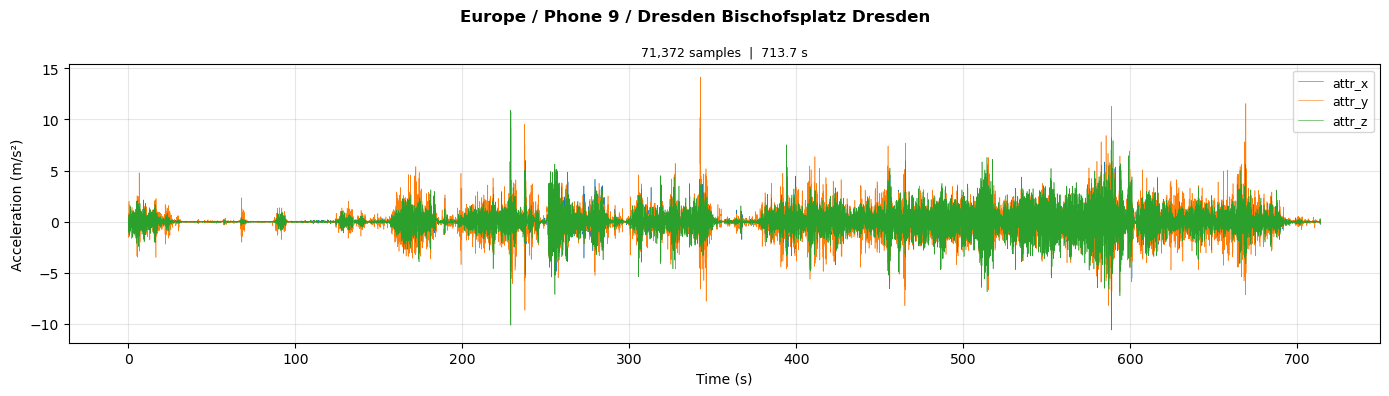

Resampled: 222433 samples @ ~50 Hz  →  446132 samples @ 100 Hz


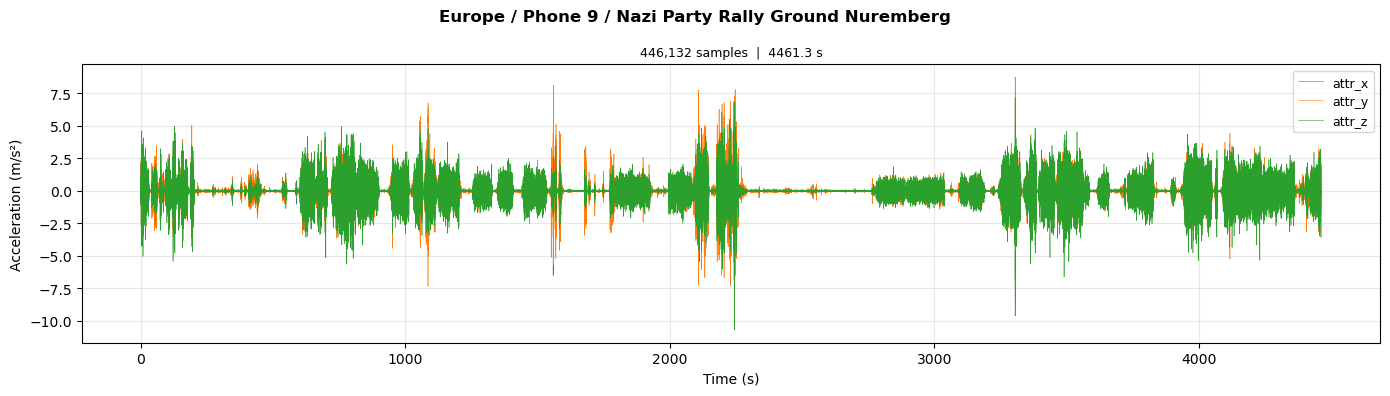

Resampled: 426777 samples @ ~13 Hz  →  3243801 samples @ 100 Hz


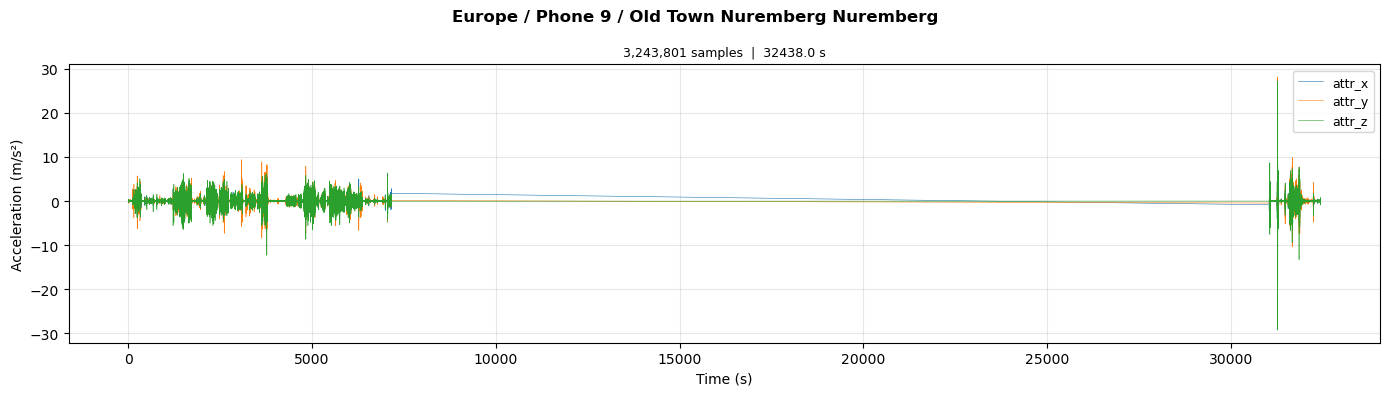

Resampled: 322312 samples @ ~50 Hz  →  646386 samples @ 100 Hz


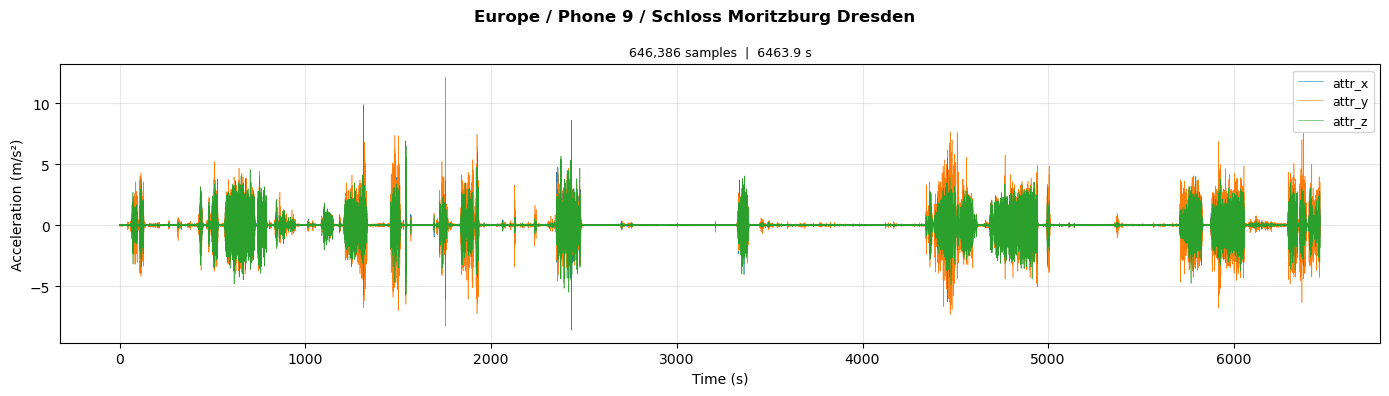

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

BASE_DIR = Path("../Datasets/Raw_Data/Unlabeled_Data_With_GPS")
accel_files = sorted(BASE_DIR.rglob("*AccelerometerData*.csv"))

print(f"Found {len(accel_files)} accelerometer files")

for f in accel_files:
    parts = f.parts
    country = parts[-4] if len(parts) >= 4 else "?"
    phone   = parts[-2] if len(parts) >= 2 else "?"
    location = f.stem.replace("_AccelerometerData", "").replace("_", " ")
    title = f"{country} / {phone} / {location}"

    try:
        df = pd.read_csv(f)

        df = trim_signal(df, trim_percent=0.05)
        df = run_butterworth(df, fs=50, highpass_cutoff=0.3, lowpass_cutoff=15, order=4)
        df = run_hampel(df, vectorized=True)
        df = remove_stalled_regions(df)
        df = resample_data(df, time_col="attr_time", signal_cols=['attr_x', 'attr_y', 'attr_z'], target_hz=100)

        time_col = "attr_time" if "attr_time" in df.columns else df.columns[1]
        t = (df[time_col] - df[time_col].iloc[0]) / 1000.0

        fig, ax = plt.subplots(figsize=(14, 4))
        fig.suptitle(title, fontsize=12, fontweight="bold")

        colors = {"attr_x": "tab:blue", "attr_y": "tab:orange", "attr_z": "tab:green"}
        for col, color in colors.items():
            if col in df.columns:
                ax.plot(t, df[col], color=color, linewidth=0.4, label=col)

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Acceleration (m/s²)")
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(True, alpha=0.3)
        duration = t.iloc[-1]
        ax.set_title(f"{len(df):,} samples  |  {duration:.1f} s", fontsize=9)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"  ERROR: {title} — {e}")


In [3]:

# ── Process all accelerometer files and save to Processed_Data ────────────────

from pathlib import Path
import pandas as pd

RAW_ROOT  = Path("../Datasets/Raw_Data")
PROC_ROOT = Path("../Datasets/Processed_Data")

RENAME = {
    "attr_time": "timestamp",
    "attr_x":    "valueX",
    "attr_y":    "valueY",
    "attr_z":    "valueZ",
}

accel_files = sorted(RAW_ROOT.rglob("*AccelerometerData*.csv"))
print(f"Found {len(accel_files)} accelerometer files to process")

skipped, saved = [], []

for raw_path in accel_files:
    rel      = raw_path.relative_to(RAW_ROOT)
    out_path = PROC_ROOT / rel
    out_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        df = pd.read_csv(raw_path)

        required = {"attr_time", "attr_x", "attr_y", "attr_z"}
        if not required.issubset(df.columns):
            raise ValueError(f"Missing columns: {required - set(df.columns)}")

        # ── Full processing pipeline ──────────────────────────────────────────
        # NOTE: resample before remove_stalled_regions so there are no timestamp
        # gaps when the resampler builds its evenly-spaced grid.
        df = trim_signal(df, trim_percent=0.05)
        df = run_butterworth(df, fs=50, highpass_cutoff=0.3, lowpass_cutoff=15, order=4)
        df = run_hampel(df, vectorized=True)
        df = resample_data(df, time_col="attr_time", target_hz=100)   # ← moved up
        # df = remove_stalled_regions(df, sampling_rate=100)
        # ─────────────────────────────────────────────────────────────────────

        df = df.rename(columns=RENAME)
        df.to_csv(out_path, index=False)
        saved.append(out_path)

    except Exception as e:
        print(f"  SKIP  {raw_path.name}  —  {e}")
        skipped.append(raw_path)

print(f"\nDone.  Saved: {len(saved)}  |  Skipped: {len(skipped)}")
if skipped:
    print("Skipped files:")
    for p in skipped:
        print(f"  {p}")


Found 25 accelerometer files to process
Resampled: 632718 samples @ ~49 Hz  →  1282857 samples @ 100 Hz
Resampled: 1092085 samples @ ~49 Hz  →  2214274 samples @ 100 Hz
Resampled: 639725 samples @ ~50 Hz  →  1282855 samples @ 100 Hz
Resampled: 1104155 samples @ ~50 Hz  →  2214268 samples @ 100 Hz
Resampled: 276846 samples @ ~49 Hz  →  561325 samples @ 100 Hz
Resampled: 148391 samples @ ~49 Hz  →  300871 samples @ 100 Hz
Resampled: 274311 samples @ ~49 Hz  →  556199 samples @ 100 Hz
Resampled: 280172 samples @ ~50 Hz  →  561869 samples @ 100 Hz
Resampled: 150030 samples @ ~50 Hz  →  300871 samples @ 100 Hz
Resampled: 277343 samples @ ~50 Hz  →  556198 samples @ 100 Hz
Resampled: 424106 samples @ ~42 Hz  →  1018447 samples @ 100 Hz
Resampled: 35197 samples @ ~49 Hz  →  71370 samples @ 100 Hz
Resampled: 220003 samples @ ~49 Hz  →  446129 samples @ 100 Hz
Resampled: 417063 samples @ ~13 Hz  →  3244936 samples @ 100 Hz
Resampled: 322075 samples @ ~49 Hz  →  653055 samples @ 100 Hz
Resampled

In [5]:
import pandas as pd
import numpy as np

windows = pd.read_csv("../Datasets/ExtractedFeatures/labeled_accelerometer_raw_windows.csv")
windows.head(2)



,valueX,valueY,valueZ,surface_id,window_id
0,-1.369181,0.157057,-0.332538,9,2
1,1.693364,-2.061905,0.230769,9,2


In [6]:
windows_list, labels_list = [], []

for wid, group in windows.groupby("window_id", sort=True):
    xyz = group[["valueX", "valueY", "valueZ"]].to_numpy(dtype=np.float32).T  # (3, T)
    sid = int(group["surface_id"].iloc[0])
    windows_list.append(xyz)
    labels_list.append(sid)

arr    = np.stack(windows_list).astype(np.float32)  # (N, 3, T)
labels = np.array(labels_list, dtype=int)


In [7]:
print(arr.shape, labels.shape)

(7962, 3, 1024) (7962,)


In [9]:
import pandas as pd

csv_path = "../Datasets/ExtractedFeatures/labeled_accelerometer_raw_windows.csv"

# Check total rows and a sample
with open(csv_path, 'r') as f:
    lines = f.readlines()

print(f"Total lines (including header): {len(lines)}")
print(f"\nFirst 3 lines (raw):")
for line in lines[:3]:
    print(repr(line))

print(f"\nLast 3 lines (raw):")
for line in lines[-3:]:
    print(repr(line))

# Check for lines with wrong number of columns
print(f"\nScanning for malformed rows...")
bad_rows = []
for i, line in enumerate(lines[1:], start=2):  # skip header
    cols = line.strip().split(',')
    if len(cols) != 5:
        bad_rows.append((i, len(cols), repr(line[:80])))

if bad_rows:
    print(f"Found {len(bad_rows)} malformed rows:")
    for row_num, col_count, preview in bad_rows[:10]:
        print(f"  Line {row_num}: {col_count} columns → {preview}")
else:
    print("All rows have exactly 5 columns.")

Total lines (including header): 8153089

First 3 lines (raw):
'valueX,valueY,valueZ,surface_id,window_id\n'
'-1.369181401048737,0.1570570655663153,-0.3325379824527033,9,2\n'
'1.6933643696309584,-2.0619048291347255,0.2307692673221953,9,2\n'

Last 3 lines (raw):
'0.3816886549385166,0.3189314917255859,1.0435648722178643,5,15823\n'
'0.1061827403159165,0.4728099058319623,-0.0861802364670271,5,15823\n'
'0.0950472192819344,0.0145032133935874,-0.2466286595716379,5,15823\n'

Scanning for malformed rows...
All rows have exactly 5 columns.


# Raw vs Processed Data Comparison

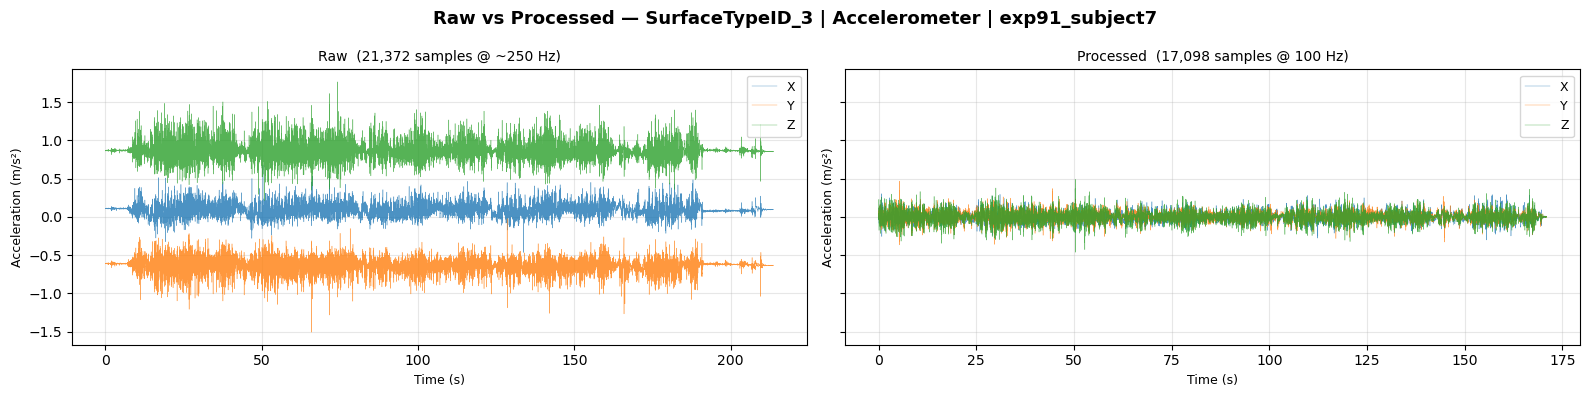

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

RAW_PATH  = "../Datasets/Raw_Data/Labeled_Data_Without_GPS/USA/SurfaceTypeID_3/2019-09-02_SurfaceTypeID_3_SamsungGalaxyJ7_exp91_subject7.csv"
PROC_PATH = "../Datasets/Processed_Data/Labeled_Data_Without_GPS/USA/SurfaceTypeID_3/2019-09-02_SurfaceTypeID_3_SamsungGalaxyJ7_exp91_subject7_Accelerometer.csv"

raw  = pd.read_csv(RAW_PATH)
proc = pd.read_csv(PROC_PATH)

raw = raw[raw['sensorName'] == 'Accelerometer'].reset_index(drop=True)
proc = proc[proc['sensorName'] == 'Accelerometer'].reset_index(drop=True)

# Normalize time to seconds from start
t_raw  = (raw["timestamp"]  - raw["timestamp"].iloc[0])  / 1000.0
t_proc = (proc["timestamp"] - proc["timestamp"].iloc[0]) / 1000.0

axes   = ["valueX", "valueY", "valueZ"]
colors = {"valueX": "tab:blue", "valueY": "tab:orange", "valueZ": "tab:green"}
labels = {"valueX": "X", "valueY": "Y", "valueZ": "Z"}

fig, axs = plt.subplots(1, 2, figsize=(16, 4), sharey=True)
fig.suptitle(
    "Raw vs Processed — SurfaceTypeID_3 | Accelerometer | exp91_subject7",
    fontsize=13, fontweight="bold"
)

for col in axes:
    axs[0].plot(t_raw,  raw[col],  color=colors[col], linewidth=0.3, alpha=0.8, label=labels[col])
    axs[1].plot(t_proc, proc[col], color=colors[col], linewidth=0.3, alpha=0.8, label=labels[col])

axs[0].set_title(f"Raw  ({len(raw):,} samples @ ~250 Hz)", fontsize=10)
axs[1].set_title(f"Processed  ({len(proc):,} samples @ 100 Hz)", fontsize=10)

for ax in axs:
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.set_ylabel("Acceleration (m/s²)", fontsize=9)
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
